In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter


# CONFIGURATION

class Config:
    DATA_PATH = '../data/processed/mitral_valve_only'
    OUTPUT_PATH = '../exported_models'
    IMG_SIZE = (224, 224)
    BATCH_SIZE = 32
    EPOCHS = 30
    INITIAL_LR = 0.0001
    RANDOM_SEED = 42
    TARGET_MINORITY_RATIO = 0.5


config = Config()
os.makedirs(config.OUTPUT_PATH, exist_ok=True)


In [3]:

# DATA LOADING


print(" LOADING AND BALANCING DATASET")


full_ds = tf.keras.preprocessing.image_dataset_from_directory(
    config.DATA_PATH,
    seed=config.RANDOM_SEED,
    image_size=config.IMG_SIZE,
    batch_size=config.BATCH_SIZE,
    label_mode='int',
    shuffle=True
)

class_names = full_ds.class_names
num_classes = len(class_names)
print(f"Classes: {class_names}")

# 70/15/15 split
dataset_size = tf.data.experimental.cardinality(full_ds).numpy()
train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size

train_ds = full_ds.take(train_size)
remaining_ds = full_ds.skip(train_size)
val_ds = remaining_ds.take(val_size)
test_ds = remaining_ds.skip(val_size)

# ============================================================================
# GET CLASS DISTRIBUTION
# ============================================================================

print("\n Class Distribution:")
labels = []
for _, y in train_ds:
    labels.extend(y.numpy().tolist())
labels = np.array(labels)

class_counts = Counter(labels)
for i, name in enumerate(class_names):
    count = class_counts.get(i, 0)
    print(f"  {name}: {count} ({count/len(labels)*100:.1f}%)")


 LOADING AND BALANCING DATASET
Found 16451 files belonging to 4 classes.
Classes: ['Grade_0', 'Grade_1', 'Grade_2', 'Grade_3']

 Class Distribution:
  Grade_0: 9012 (78.2%)
  Grade_1: 1333 (11.6%)
  Grade_2: 444 (3.9%)
  Grade_3: 731 (6.3%)


2026-06-24 17:47:42.090271: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:

# SAMPLING STRATEGY

print("\n🔄 Applying Sampling Strategy...")

def balance_dataset(dataset, class_names, target_ratio=0.5):
    """Oversample minority classes to reach target ratio."""
    
    # Extract all data
    images = []
    labels = []
    
    for img_batch, label_batch in dataset:
        images.extend(img_batch.numpy())
        labels.extend(label_batch.numpy())
    
    images = np.array(images)
    labels = np.array(labels)
    
    # Calculate target samples
    majority_count = max(Counter(labels).values())
    target_samples = {}
    
    for class_id in np.unique(labels):
        if class_id == 0:  # Majority class
            target_samples[class_id] = majority_count
        else:
            target_samples[class_id] = int(majority_count * target_ratio)
    
    # Resample
    balanced_images = []
    balanced_labels = []
    
    for class_id in np.unique(labels):
        class_mask = labels == class_id
        class_images = images[class_mask]
        class_labels = labels[class_mask]
        n_samples = target_samples[class_id]
        
        if len(class_images) == 0:
            continue
            
        if len(class_images) < n_samples:
            # Oversample with replacement
            indices = np.random.choice(len(class_images), n_samples, replace=True)
        else:
            # Undersample without replacement
            indices = np.random.choice(len(class_images), n_samples, replace=False)
            
        balanced_images.extend(class_images[indices])
        balanced_labels.extend(class_labels[indices])
    
    return np.array(balanced_images), np.array(balanced_labels)

# Apply balancing
balanced_images, balanced_labels = balance_dataset(
    train_ds, class_names, config.TARGET_MINORITY_RATIO
)

print(f"\nBalanced distribution:")
for i, name in enumerate(class_names):
    count = np.sum(balanced_labels == i)
    print(f"  {name}: {count} ({count/len(balanced_labels)*100:.1f}%)")



🔄 Applying Sampling Strategy...


2026-06-22 10:39:19.655069: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Balanced distribution:
  Grade_0: 9010 (40.0%)
  Grade_1: 4505 (20.0%)
  Grade_2: 4505 (20.0%)
  Grade_3: 4505 (20.0%)


In [4]:
# ============================================================================
# CREATE TENSORFLOW DATASET
# ============================================================================

def create_tf_dataset(images, labels, batch_size, shuffle=True):
    """Create TensorFlow dataset from numpy arrays."""
    dataset = tf.data.Dataset.from_tensor_slices((images, labels))
    if shuffle:
        dataset = dataset.shuffle(len(images), seed=config.RANDOM_SEED)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

train_ds_balanced = create_tf_dataset(
    balanced_images, balanced_labels, config.BATCH_SIZE, shuffle=True
)

In [5]:
# ============================================================================
# CLASS WEIGHTS
# ============================================================================

print("\n⚖️  Calculating Class Weights (Post-Sampling)...")

balanced_labels_array = balanced_labels
unique_classes = np.unique(balanced_labels_array)
weights = class_weight.compute_class_weight(
    'balanced',
    classes=unique_classes,
    y=balanced_labels_array
)

# Gentle medical boost
medical_boost = [1.0, 1.1, 1.3, 1.5]
weights = weights * medical_boost[:len(class_names)]

# Normalize
weights = weights / weights.mean() * len(class_names) / 2
class_weights = dict(enumerate(weights))

print("Class weights:")
for i, name in enumerate(class_names):
    print(f"  {name}: {weights[i]:.3f}")


⚖️  Calculating Class Weights (Post-Sampling)...
Class weights:
  Grade_0: 0.909
  Grade_1: 2.000
  Grade_2: 2.364
  Grade_3: 2.727


In [6]:
def augment_dataset(image, label):
    """Augmentation for training - Compatible version."""
    
    # Random horizontal flip (50% chance)
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
    
    # Random brightness
    image = tf.image.random_brightness(image, 0.1)
    
    # Random contrast
    image = tf.image.random_contrast(image, 0.9, 1.1)
    
    # Random saturation
    image = tf.image.random_saturation(image, 0.9, 1.1)
    
    # Random hue (small adjustment)
    image = tf.image.random_hue(image, 0.05)
    
    # Clip to valid range
    image = tf.clip_by_value(image, 0, 255)
    
    return image, label

In [7]:
# ============================================================================
# PREPARE DATASETS 
# ============================================================================

AUTOTUNE = tf.data.AUTOTUNE

# Training set with augmentation AND repeat - IMPORTANT!
train_ds_final = train_ds_balanced.repeat().map(
    augment_dataset, 
    num_parallel_calls=AUTOTUNE
)
train_ds_final = train_ds_final.prefetch(AUTOTUNE)

# Validation set with repeat
val_ds_final = val_ds.repeat().prefetch(AUTOTUNE)

# Test set (no repeat)
test_ds_final = test_ds.prefetch(AUTOTUNE)

# Calculate steps
steps_per_epoch = len(balanced_images) // config.BATCH_SIZE
validation_steps = tf.data.experimental.cardinality(val_ds).numpy()

print(f"\nSteps per epoch: {steps_per_epoch}")
print(f"Validation steps: {validation_steps}")


Steps per epoch: 703
Validation steps: 77


In [8]:


# ============================================================================
# BUILD MODEL
# ============================================================================

print("\n🔨 BUILDING MODEL")
print("="*60)

model = models.Sequential([
    layers.Input(shape=(*config.IMG_SIZE, 3)),
    layers.Rescaling(1./255),
    
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Dropout(0.25),
    
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Dropout(0.25),
    
    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Dropout(0.25),
    
    layers.Conv2D(256, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),
    
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

optimizer = tf.keras.optimizers.Adam(learning_rate=config.INITIAL_LR)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


🔨 BUILDING MODEL


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 424,260 (1.62 MB)

 Trainable params: 423,044 (1.61 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [9]:


# ============================================================================
# CALLBACKS
# ============================================================================

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(config.OUTPUT_PATH, 'models', 'best_model.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]


In [10]:

# ============================================================================
# TRAINING
# ============================================================================

print("\n" + "="*60)
print("🚀 STARTING TRAINING (Hybrid: Sampling + Weights)")
print("="*60)
print(f"Learning rate: {config.INITIAL_LR}")
print(f"Class weights: {class_weights}")
print(f"Target minority ratio: {config.TARGET_MINORITY_RATIO}")

history = model.fit(
    train_ds_final,
    validation_data=val_ds_final,
    epochs=config.EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)



🚀 STARTING TRAINING (Hybrid: Sampling + Weights)
Learning rate: 0.0001
Class weights: {0: 0.9090909090909091, 1: 2.0, 2: 2.3636363636363638, 3: 2.727272727272727}
Target minority ratio: 0.5
Epoch 1/30
703/703 ━━━━━━━━━━━━━━━━━━━━ 0s 967ms/step - accuracy: 0.3281 - loss: 3.0972
Epoch 1: val_accuracy improved from None to 0.57427, saving model to ../exported_models/models/best_model.keras

Epoch 1: finished saving model to ../exported_models/models/best_model.keras
703/703 ━━━━━━━━━━━━━━━━━━━━ 709s 995ms/step - accuracy: 0.3562 - loss: 2.9211 - val_accuracy: 0.5743 - val_loss: 1.2328 - learning_rate: 1.0000e-04
Epoch 2/30
703/703 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3946 - loss: 2.6883
Epoch 2: val_accuracy improved from 0.57427 to 0.70860, saving model to ../exported_models/models/best_model.keras

Epoch 2: finished saving model to ../exported_models/models/best_model.keras
703/703 ━━━━━━━━━━━━━━━━━━━━ 797s 1s/step - accuracy: 0.3970 - loss: 2.6420 - val_accuracy: 0.7086 - val


 EVALUATING ON TEST SET
78/78 ━━━━━━━━━━━━━━━━━━━━ 13s 141ms/step - accuracy: 0.7965 - loss: 1.6060

Test Accuracy: 0.7965
Test Loss: 1.6060


2026-06-22 15:14:14.951548: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/Users/sola/miniforge3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sola/miniforge3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sola/miniforge3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no 


Classification Report:
              precision    recall  f1-score   support

     Grade_0     0.8117    0.9847    0.8899      1961
     Grade_1     0.0000    0.0000    0.0000       269
     Grade_2     0.0000    0.0000    0.0000        79
     Grade_3     0.4177    0.2089    0.2785       158

    accuracy                         0.7961      2467
   macro avg     0.3074    0.2984    0.2921      2467
weighted avg     0.6720    0.7961    0.7252      2467



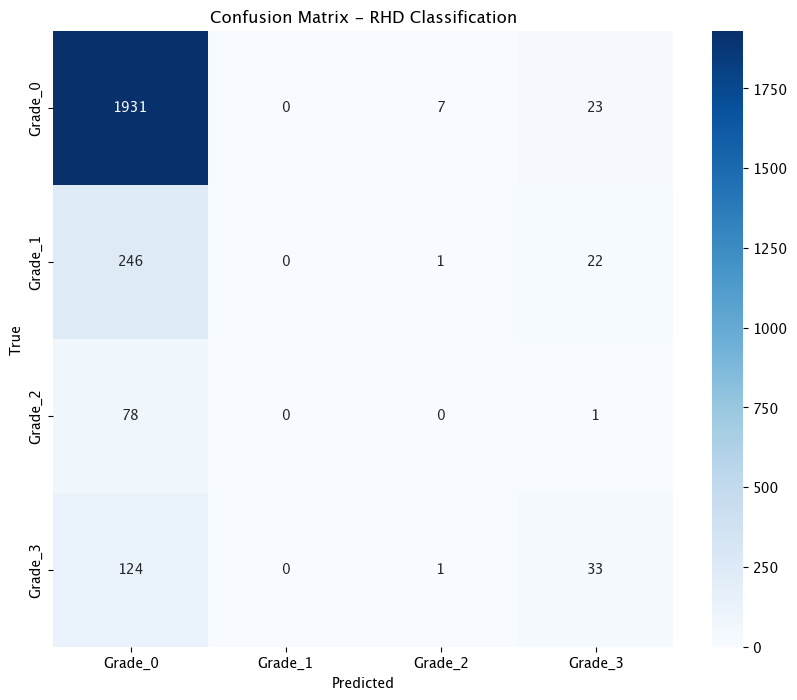

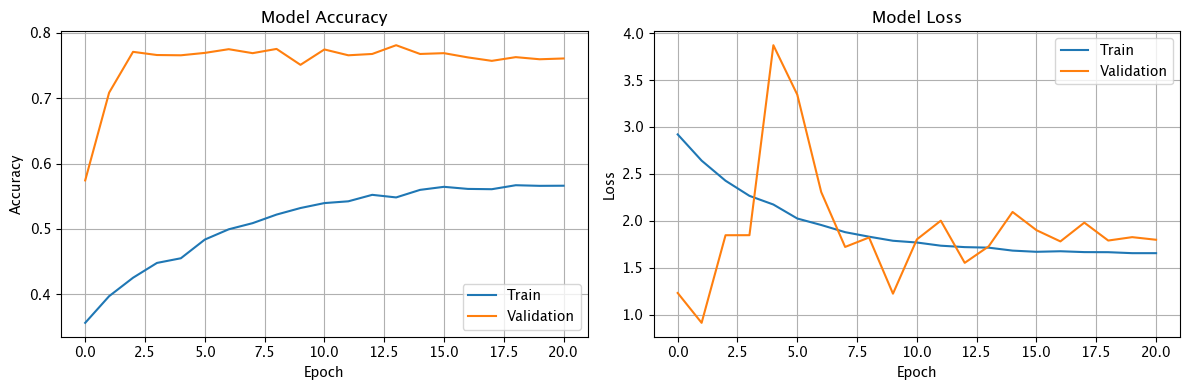


 Training Complete!
Best validation accuracy: 0.7812
Test accuracy: 0.7965


In [11]:

# ============================================================================
# EVALUATION
# ============================================================================

print("\n EVALUATING ON TEST SET")
print("="*60)

test_loss, test_acc = model.evaluate(test_ds_final, verbose=1)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Predictions
y_true = []
y_pred = []

for images, labels in test_ds_final:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - RHD Classification')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\n Training Complete!")
print(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Test accuracy: {test_acc:.4f}")